In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from skimage.io import imread

# Reproducibility (score-neutral, stability-only)
import random

random.seed(42)
np.random.seed(42)

# Prefer TF-Keras to avoid keras/protobuf runtime issues on Kaggle
import tensorflow as tf

tf.random.set_seed(42)

print("TF version:", tf.__version__)

# Resolve dataset root robustly (works with /kaggle/input/... structure)
INPUT_ROOT = "/kaggle/input"
if not os.path.exists(INPUT_ROOT):
    # fallback for environments that mount as ../input
    INPUT_ROOT = "../input"

print("Input root:", INPUT_ROOT)
print(
    "Available competitions/datasets under input root (first 20):",
    os.listdir(INPUT_ROOT)[:20],
)

# This competition is typically mounted as /kaggle/input/aerial-cactus-identification
DATA_DIR = os.path.join(INPUT_ROOT, "aerial-cactus-identification")
if not os.path.exists(DATA_DIR):
    # fallback to nested path from the prompt (keep minimal but robust)
    # some environments may have /kaggle/input/aerial-cactus-identification/aerial-cactus-identification/
    alt = os.path.join(
        INPUT_ROOT, "aerial-cactus-identification", "aerial-cactus-identification"
    )
    if os.path.exists(alt):
        DATA_DIR = alt

print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", os.path.exists(DATA_DIR))

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
SAMPLE_SUB = os.path.join(DATA_DIR, "sample_submission.csv")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

for p in [TRAIN_CSV, SAMPLE_SUB, TRAIN_DIR, TEST_DIR]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING")



2026-05-10 21:21:01.962113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778448061.971104      56 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778448061.973824      56 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 21:21:01.985030: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0
Input root: /kaggle/input
Available competitions/datasets under input root (first 20): ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']
DATA_DIR: /kaggle/input/aerial-cactus-identification
DATA_DIR exists: True
/kaggle/input/aerial-cactus-identification/train.csv -> OK
/kaggle/input/aerial-cactus-identification/sample_submission.csv -> OK
/kaggle/input/aerial-cactus-identification/train -> OK
/kaggle/input/aerial-cactus-identification/test -> OK


In [2]:
# Load train labels + sample submission (fixes missing ../input/firstaa/submission.csv)
train = pd.read_csv(TRAIN_CSV)
sub = pd.read_csv(SAMPLE_SUB)

print(train.shape, train.columns.tolist())
print(sub.shape, sub.columns.tolist())

# Basic sanity
assert set(["id", "has_cactus"]).issubset(train.columns)
assert set(["id", "has_cactus"]).issubset(sub.columns)



(14175, 2) ['id', 'has_cactus']
(3325, 2) ['id', 'has_cactus']


In [3]:
# Read images into numpy arrays (32x32 RGB)
IMG_SIZE = 32


def load_images(id_list, folder):
    X = np.zeros((len(id_list), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    for i, img_id in enumerate(id_list):
        img_path = os.path.join(folder, img_id)
        img = imread(img_path)

        # Ensure 3-channel
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.shape[-1] == 4:
            img = img[..., :3]

        # Convert to float32 and scale to [0,1]
        X[i] = img.astype(np.float32) / 255.0
    return X


y_train = train["has_cactus"].values.astype(np.float32)

# Load full train/test (small images; should fit in RAM)
X_train = load_images(train["id"].tolist(), TRAIN_DIR)
X_test = load_images(sub["id"].tolist(), TEST_DIR)

print("X_train:", X_train.shape, X_train.dtype, "y_train:", y_train.shape)
print("X_test:", X_test.shape, X_test.dtype)



X_train: (14175, 32, 32, 3) float32 y_train: (14175,)
X_test: (3325, 32, 32, 3) float32


In [4]:
# Train/val split
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print("Train split:", X_tr.shape, y_tr.mean())
print("Val split:", X_val.shape, y_val.mean())



Train split: (12048, 32, 32, 3) 0.749751
Val split: (2127, 32, 32, 3) 0.74988246


In [5]:
# Model: ResNet50 backbone + GAP + Dense/Dropout head (core logic preserved)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ResNet50 expects >=32x32, so 32x32 is valid
inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base = ResNet50(include_top=False, weights="imagenet", input_tensor=inp)

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base.input, outputs=x)

# Compile (fix deprecated lr arg)
model.compile(
    loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-4), metrics=["accuracy"]
)
model.summary()



2026-05-10 21:21:51.929317: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778448111.929743      56 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 23,536,641 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [6]:
# Callbacks (fix deprecated epsilon arg; keep intent)
red = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=10,
    verbose=1,
    mode="auto",
    cooldown=0,
    min_lr=0.0,
)
early_stopping = EarlyStopping(
    monitor="val_loss", patience=20, verbose=1, restore_best_weights=True
)



In [7]:
# Fit (no early stopping changes beyond making it functional; restore_best_weights for correctness)
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[red, early_stopping],
    verbose=2,
)



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 32, 32, 3))
  warnings.warn(msg)
I0000 00:00:1778448132.334262     109 service.cc:148] XLA service 0x7f7030005620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778448132.334288     109 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-10 21:22:12.824349: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778448135.004822     109 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778448144.501349     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


189/189 - 48s - 253ms/step - accuracy: 0.9133 - loss: 0.2331 - val_accuracy: 0.2501 - val_loss: 55.9388 - learning_rate: 1.0000e-04
Epoch 2/20
189/189 - 3s - 18ms/step - accuracy: 0.9895 - loss: 0.0316 - val_accuracy: 0.2501 - val_loss: 76.4172 - learning_rate: 1.0000e-04
Epoch 3/20
189/189 - 3s - 18ms/step - accuracy: 0.9979 - loss: 0.0069 - val_accuracy: 0.2501 - val_loss: 78.7593 - learning_rate: 1.0000e-04
Epoch 4/20
189/189 - 3s - 18ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.2642 - val_loss: 24.2588 - learning_rate: 1.0000e-04
Epoch 5/20
189/189 - 3s - 16ms/step - accuracy: 1.0000 - loss: 6.6573e-04 - val_accuracy: 0.5407 - val_loss: 2.2270 - learning_rate: 1.0000e-04
Epoch 6/20
189/189 - 3s - 15ms/step - accuracy: 1.0000 - loss: 4.3794e-04 - val_accuracy: 0.9027 - val_loss: 0.4387 - learning_rate: 1.0000e-04
Epoch 7/20
189/189 - 3s - 18ms/step - accuracy: 1.0000 - loss: 2.8976e-04 - val_accuracy: 0.9859 - val_loss: 0.0644 - learning_rate: 1.0000e-04
Epoch 8/20
18

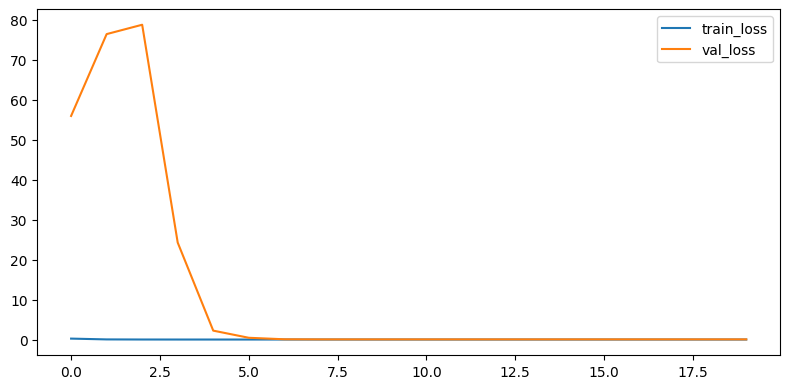

In [8]:
# Optional training curve plot (non-blocking)
plt.figure(figsize=(8, 4))
plt.plot(history.history.get("loss", []), label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.legend()
plt.tight_layout()
plt.show()



In [9]:
# Predict probabilities for submission (AUC metric wants probabilities, not hard labels)
pred = model.predict(X_test, batch_size=128, verbose=0).reshape(-1)

submission = sub.copy()
submission["has_cactus"] = pred.astype(np.float32)

# Ensure correct order and format
submission = submission[["id", "has_cactus"]]
print(submission.head())
print(submission["has_cactus"].describe())



/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(128, 32, 32, 3))
  warnings.warn(msg)


                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.999997
1  134f04305c795d6d202502c2ce3578f3.jpg    1.000000
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999992
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999991
4  b77dc902b035887cbbc01920ce0e3151.jpg    1.000000
count    3325.000000
mean        0.752648
std         0.429283
min         0.000000
25%         0.829459
50%         0.999971
75%         0.999997
max         1.000000
Name: has_cactus, dtype: float64


In [10]:
# Write valid CSV submission
out_path = "submission.csv"
submission.to_csv(out_path, index=False)
print("Wrote:", out_path, "rows:", len(submission))
print("File exists:", os.path.exists(out_path))

Wrote: submission.csv rows: 3325
File exists: True
